# Imports

In [1]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group, exist_pred

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Snapshots

## load config

In [ ]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
baselines = pd.read_csv(f'{save_root}/baselines_params.csv')
finetunes_best = pd.read_csv(f'{save_root}/best_finetune_full_each.csv')

model_list = ['Fredformer', 'iTransformer', 'FreTS', 'DLinear']

base = baselines.copy()
base = base[
    # ((base.data_id == 'ETTh1') & (base.model.isin(model_list))) |
    # ((base.data_id == 'ETTh2') & (base.model.isin(model_list))) |
    # ((base.data_id == 'ETTm1') & (base.model.isin(model_list))) |
    ((base.data_id == 'ETTm2') & (base.model.isin(model_list))) |
    ((base.data_id == 'ECL') & (base.model.isin(model_list)))
]

best = finetunes_best.copy()
best = best[best.pred_len != 'Avg']
best = best[
    # ((best.data_id == 'ETTh1_PCA') & (best.model.isin(model_list))) |
    # ((best.data_id == 'ETTh2_PCA') & (best.model.isin(model_list))) |
    # ((best.data_id == 'ETTm1_PCA') & (best.model.isin(model_list))) |
    ((best.data_id == 'ETTm2_PCA') & (best.model.isin(model_list))) |
    ((best.data_id == 'ECL_PCA') & (best.model.isin(model_list)))
]


In [3]:
columns = ['model', 'data_id', 'pred_len', 'mse', 'mae']

# df_show = base[columns].copy()
df_show = best[columns].copy()
df_show.sort_values(by=['data_id', 'model', 'pred_len'], inplace=True)
df_show

,model,data_id,pred_len,mse,mae
126,DLinear,ECL_PCA,192,0.193919,0.279426
127,DLinear,ECL_PCA,336,0.206861,0.294570
128,DLinear,ECL_PCA,720,0.242502,0.328900
125,DLinear,ECL_PCA,96,0.194632,0.275993
121,FreTS,ECL_PCA,192,0.182575,0.268897
122,FreTS,ECL_PCA,336,0.196722,0.285411
123,FreTS,ECL_PCA,720,0.232992,0.318748
120,FreTS,ECL_PCA,96,0.178489,0.262438
106,Fredformer,ECL_PCA,192,0.165649,0.256300
107,Fredformer,ECL_PCA,336,0.181096,0.274290


## load data

In [8]:
data = {}

print("process baselines ...\n\n")
for i, row in base.iterrows():
    exp_dir = row['exp_dir']
    runned, setting_dir = exist_pred(exp_dir)
    if not runned:
        print(os.path.basename(exp_dir), 'has no prediction!!')
        continue
    else:
        print(os.path.basename(exp_dir), ' ---> processing ...')

    model, data_id, pred_len = row['model'], row['data_id'], row['pred_len']
    inputs = load_npy(os.path.join(setting_dir, 'input.npy'))[..., -1]
    preds = load_npy(os.path.join(setting_dir, 'pred.npy'))[..., -1]
    trues = load_npy(os.path.join(setting_dir, 'true.npy'))[..., -1]

    gt_ = np.concatenate([inputs, trues], axis=1)
    pd_ = np.concatenate([inputs, preds], axis=1)

    del inputs, preds, trues
    data[f"{model}_{data_id}_{pred_len}"] = [gt_, pd_]


print("process finetunes ...\n\n")
for i, row in best.iterrows():
    exp_dir = row['exp_dir']
    runned, setting_dir = exist_pred(exp_dir)
    if not runned:
        print(os.path.basename(exp_dir), 'has no prediction!!')
        continue
    else:
        print(os.path.basename(exp_dir), ' ---> processing ...')

    try:
        model, data_id, pred_len = row['model'], row['data_id'], row['pred_len']
        inputs = load_npy(os.path.join(setting_dir, 'input.npy'))[..., -1]
        preds = load_npy(os.path.join(setting_dir, 'pred.npy'))[..., -1]
        trues = load_npy(os.path.join(setting_dir, 'true.npy'))[..., -1]
        pca_components = load_npy(os.path.join(setting_dir, 'pca_components.npy'))
        data[f"{model}_{data_id}_{pred_len}_Base"] = pca_components[-1]

        gt_ = np.concatenate([inputs, trues], axis=1)
        pd_ = np.concatenate([inputs, preds], axis=1)

        del inputs, preds, trues
        data[f"{model}_{data_id}_{pred_len}"] = [gt_, pd_]
    except Exception as e:
        print(f"Error processing {os.path.basename(exp_dir)}: {e}")
        continue

process baselines ...


DLinear_ECL_96_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ECL_192_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ECL_336_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ECL_720_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ETTm2_96_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ETTm2_192_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ETTm2_336_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
DLinear_ETTm2_720_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
FreTS_ECL_96_1.0_0.0_0.0005_type1_10_3_16  ---> processing ...
FreTS_ECL_192_1.0_0.0_0.0005_type1_10_3_16  ---> processing ...
FreTS_ECL_336_1.0_0.0_0.0005_type1_10_3_16  ---> processing ...
FreTS_ECL_720_1.0_0.0_0.0005_type1_10_3_16  ---> processing ...
FreTS_ETTm2_96_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
FreTS_ETTm2_192_1.0_0.0_0.0005_type1_10_3_32  ---> processing ...
FreTS_ETTm2_336_1.0_0.0_0.0005_type1_10_3_32  ---> proce

In [9]:
for k, v in data.items():
    if isinstance(v, list):
        print(k, v[0].shape, v[1].shape)
    else:
        print(k, v.shape)

DLinear_ECL_96 (5165, 192) (5165, 192)
DLinear_ECL_192 (5069, 288) (5069, 288)
DLinear_ECL_336 (4925, 432) (4925, 432)
DLinear_ECL_720 (4541, 816) (4541, 816)
DLinear_ETTm2_96 (11425, 192) (11425, 192)
DLinear_ETTm2_192 (11329, 288) (11329, 288)
DLinear_ETTm2_336 (11185, 432) (11185, 432)
DLinear_ETTm2_720 (10801, 816) (10801, 816)
FreTS_ECL_96 (5165, 192) (5165, 192)
FreTS_ECL_192 (5069, 288) (5069, 288)
FreTS_ECL_336 (4925, 432) (4925, 432)
FreTS_ECL_720 (4541, 816) (4541, 816)
FreTS_ETTm2_96 (11425, 192) (11425, 192)
FreTS_ETTm2_192 (11329, 288) (11329, 288)
FreTS_ETTm2_336 (11185, 432) (11185, 432)
FreTS_ETTm2_720 (10801, 816) (10801, 816)
Fredformer_ECL_96 (5165, 192) (5165, 192)
Fredformer_ECL_192 (5069, 288) (5069, 288)
Fredformer_ECL_336 (4925, 432) (4925, 432)
Fredformer_ECL_720 (4541, 816) (4541, 816)
Fredformer_ETTm2_96 (11425, 192) (11425, 192)
Fredformer_ETTm2_192 (11329, 288) (11329, 288)
Fredformer_ETTm2_336 (11185, 432) (11185, 432)
Fredformer_ETTm2_720 (10801, 816) (10

## preprocess

In [70]:
idxs = {}

for model in ['Fredformer']:
    for data_id in ['ETTm2']:
        for pl in [336]:
# for model in ['iTransformer']:
# for model in ['DLinear']:
    # for data_id in ['ECL']:
        # for pl in [192]:
            base_data = {k: v for k, v in data.items() if data_id in k and 'PCA' not in k and str(pl) in k and 'Base' not in k and model in k}
            base_data = list(base_data.values())[0]
            base_mse = np.mean(np.square(base_data[0][:, -pl:] - base_data[1][:, -pl:]), axis=1)

            pca_data = {k: v for k, v in data.items() if data_id in k and 'PCA' in k and str(pl) in k and 'Base' not in k and model in k}
            pca_data = list(pca_data.values())[0]
            pca_mse = np.mean(np.square(pca_data[0][:, -pl:] - pca_data[1][:, -pl:]), axis=1)
            # 找到pcamse和base mse之间差距最大，并且pcamse较小的index排序
            diff = pca_mse - base_mse
            idx = np.argsort(diff)
            # 选取前50个
            idx = idx[:100]
            pca_min = pca_mse[idx]
            for i in idx:
                print(f'{data_id} {pl} index {i} diff {diff[i]} pca mse {pca_mse[i]} base mse {base_mse[i]}')
            min_pca_idx = np.argsort(pca_min)[0]
            idxs[f'{data_id}_{pl}'] = idx[min_pca_idx]
            print(f'{data_id} {pl} index {idx[min_pca_idx]}')

ETTm2 336 index 533 diff -0.3090941309928894 pca mse 0.1417071372270584 base mse 0.4508012533187866
ETTm2 336 index 535 diff -0.29633796215057373 pca mse 0.14623785018920898 base mse 0.4425758123397827
ETTm2 336 index 529 diff -0.2935340404510498 pca mse 0.15357615053653717 base mse 0.4471101760864258
ETTm2 336 index 2258 diff -0.29157596826553345 pca mse 0.33772921562194824 base mse 0.6293051838874817
ETTm2 336 index 534 diff -0.29088151454925537 pca mse 0.15624862909317017 base mse 0.44713014364242554
ETTm2 336 index 536 diff -0.28717127442359924 pca mse 0.14003294706344604 base mse 0.4272042214870453
ETTm2 336 index 7852 diff -0.2789687216281891 pca mse 0.3524656593799591 base mse 0.6314343810081482
ETTm2 336 index 532 diff -0.277743935585022 pca mse 0.14208899438381195 base mse 0.4198329448699951
ETTm2 336 index 530 diff -0.2714460492134094 pca mse 0.14738716185092926 base mse 0.4188332259654999
ETTm2 336 index 2257 diff -0.2705767750740051 pca mse 0.3417001962661743 base mse 0.612

## plot

iTrans ECL 192 index 2452
0.270695
Fredformer ECL 192 index 2452
0.2840333


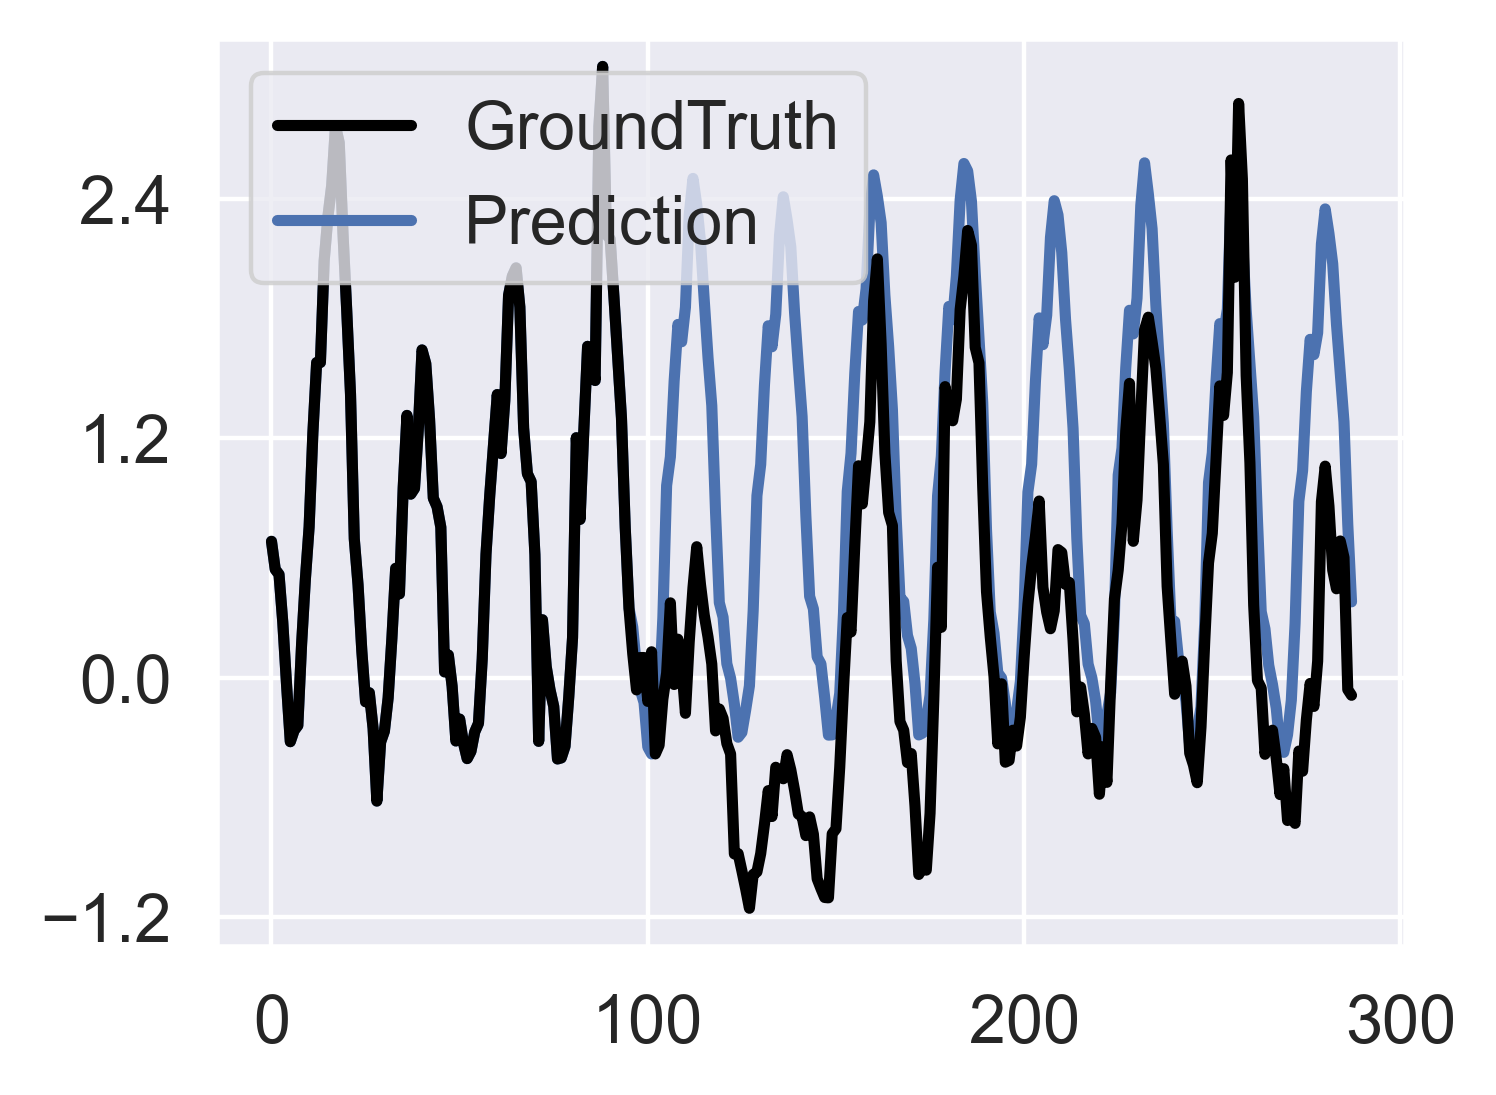

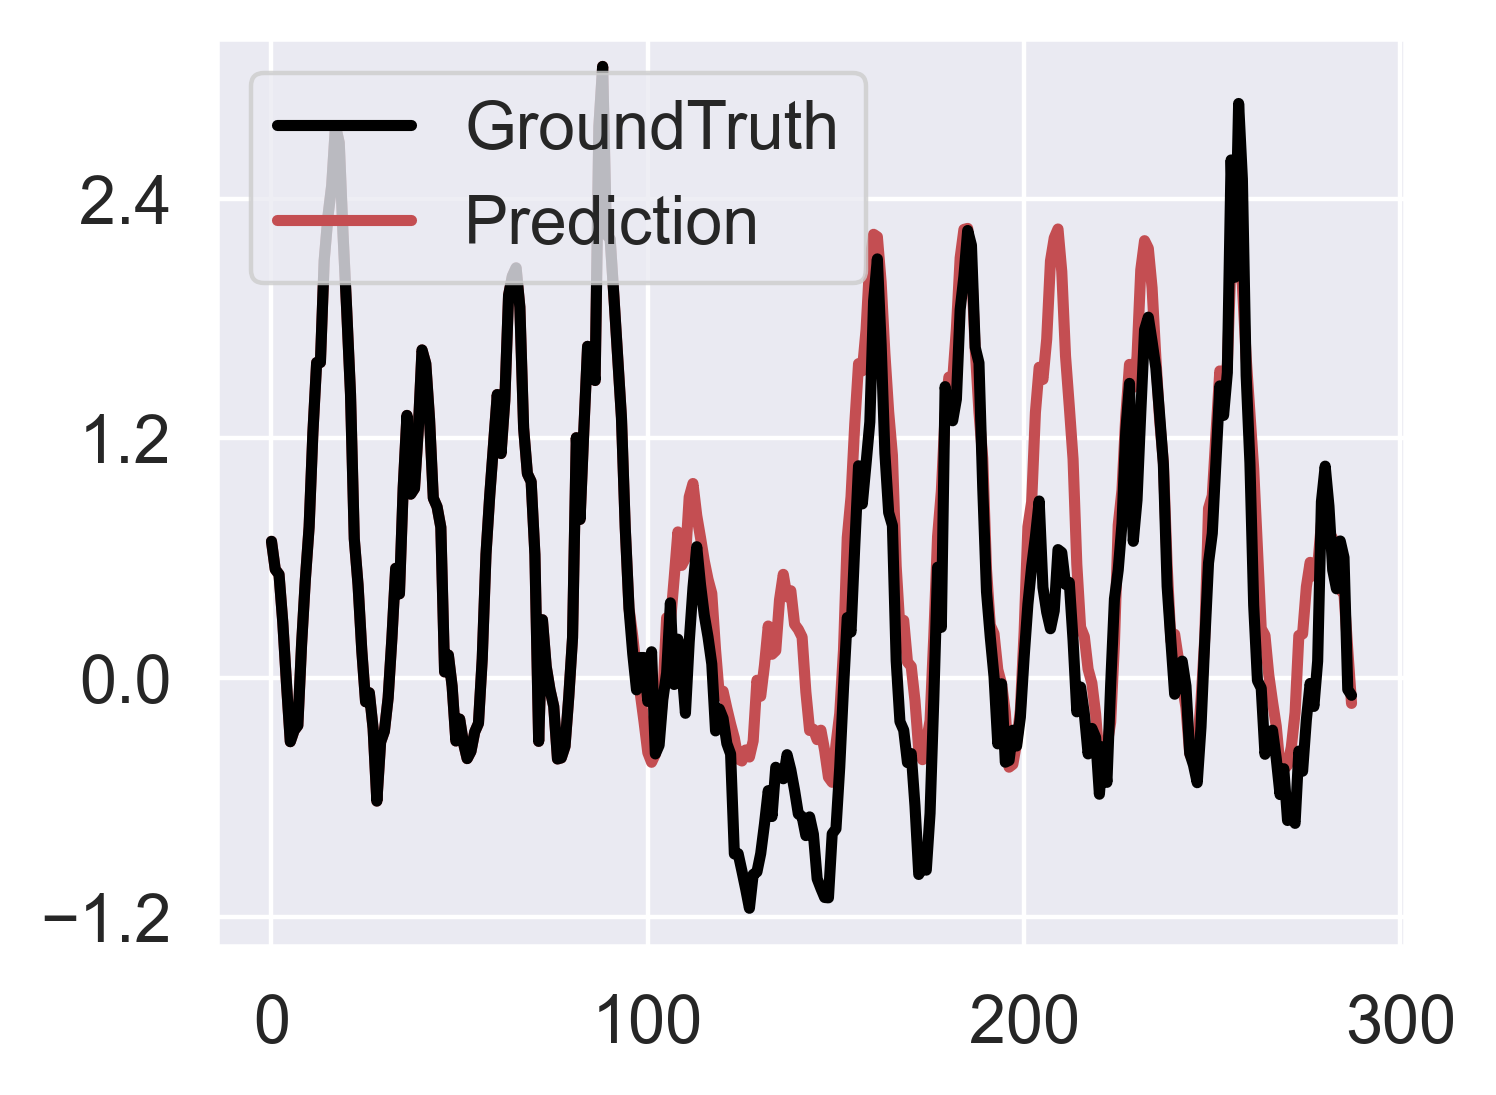

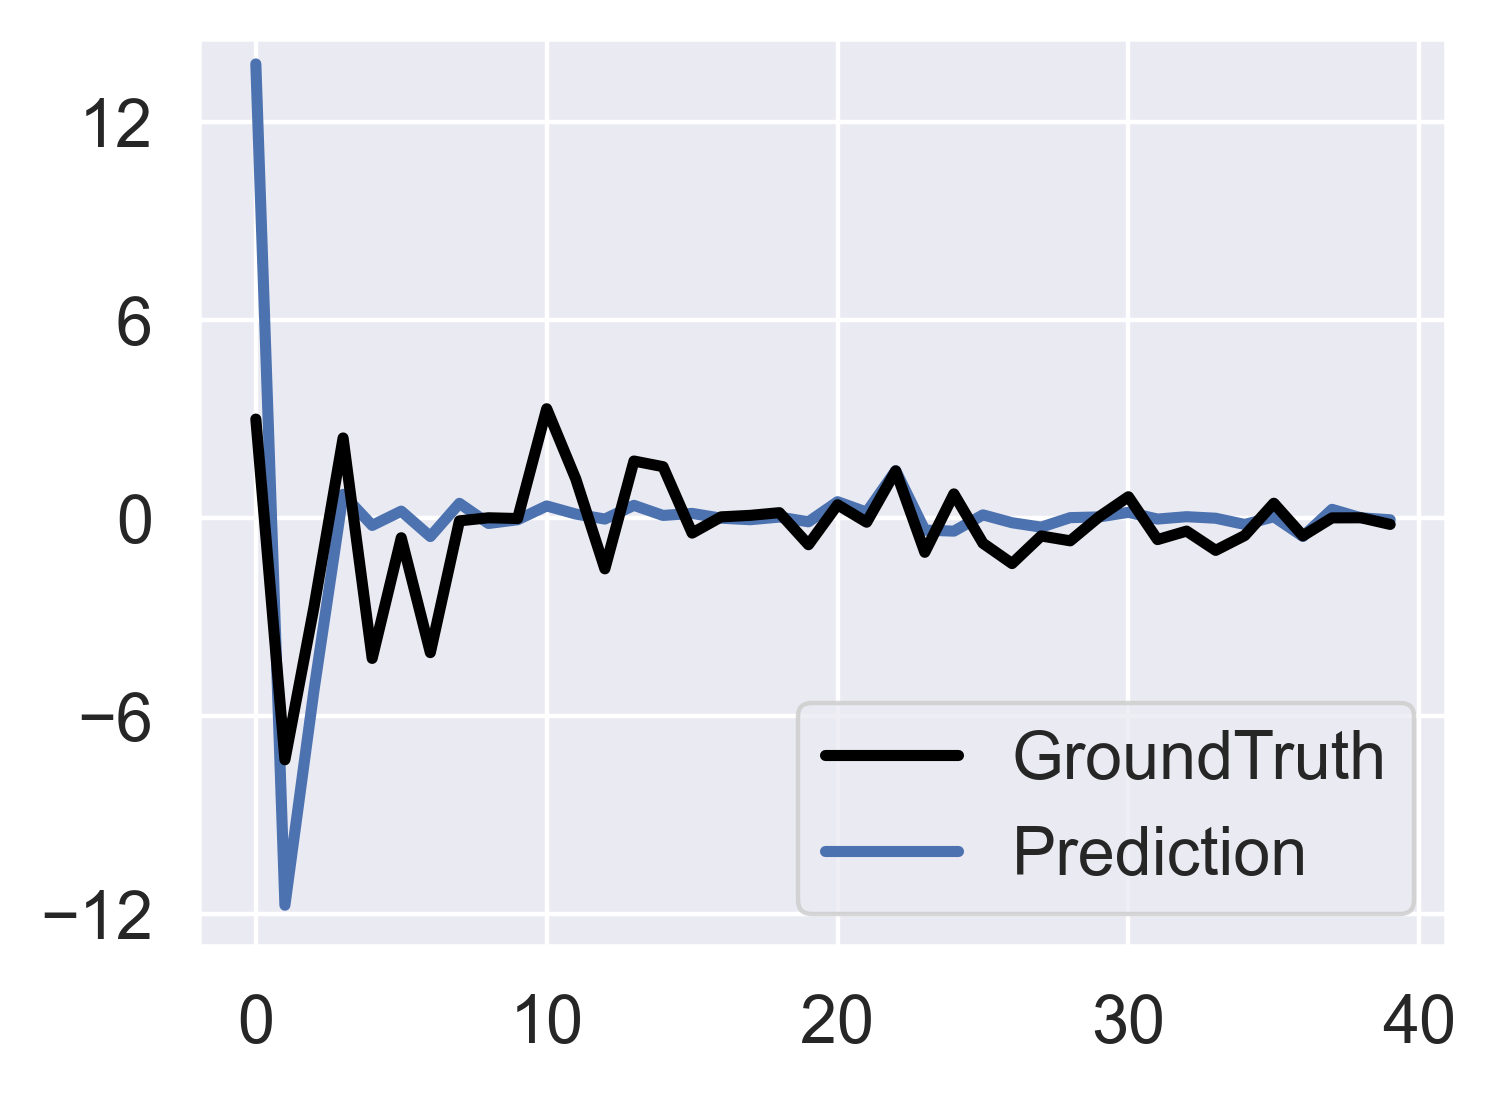

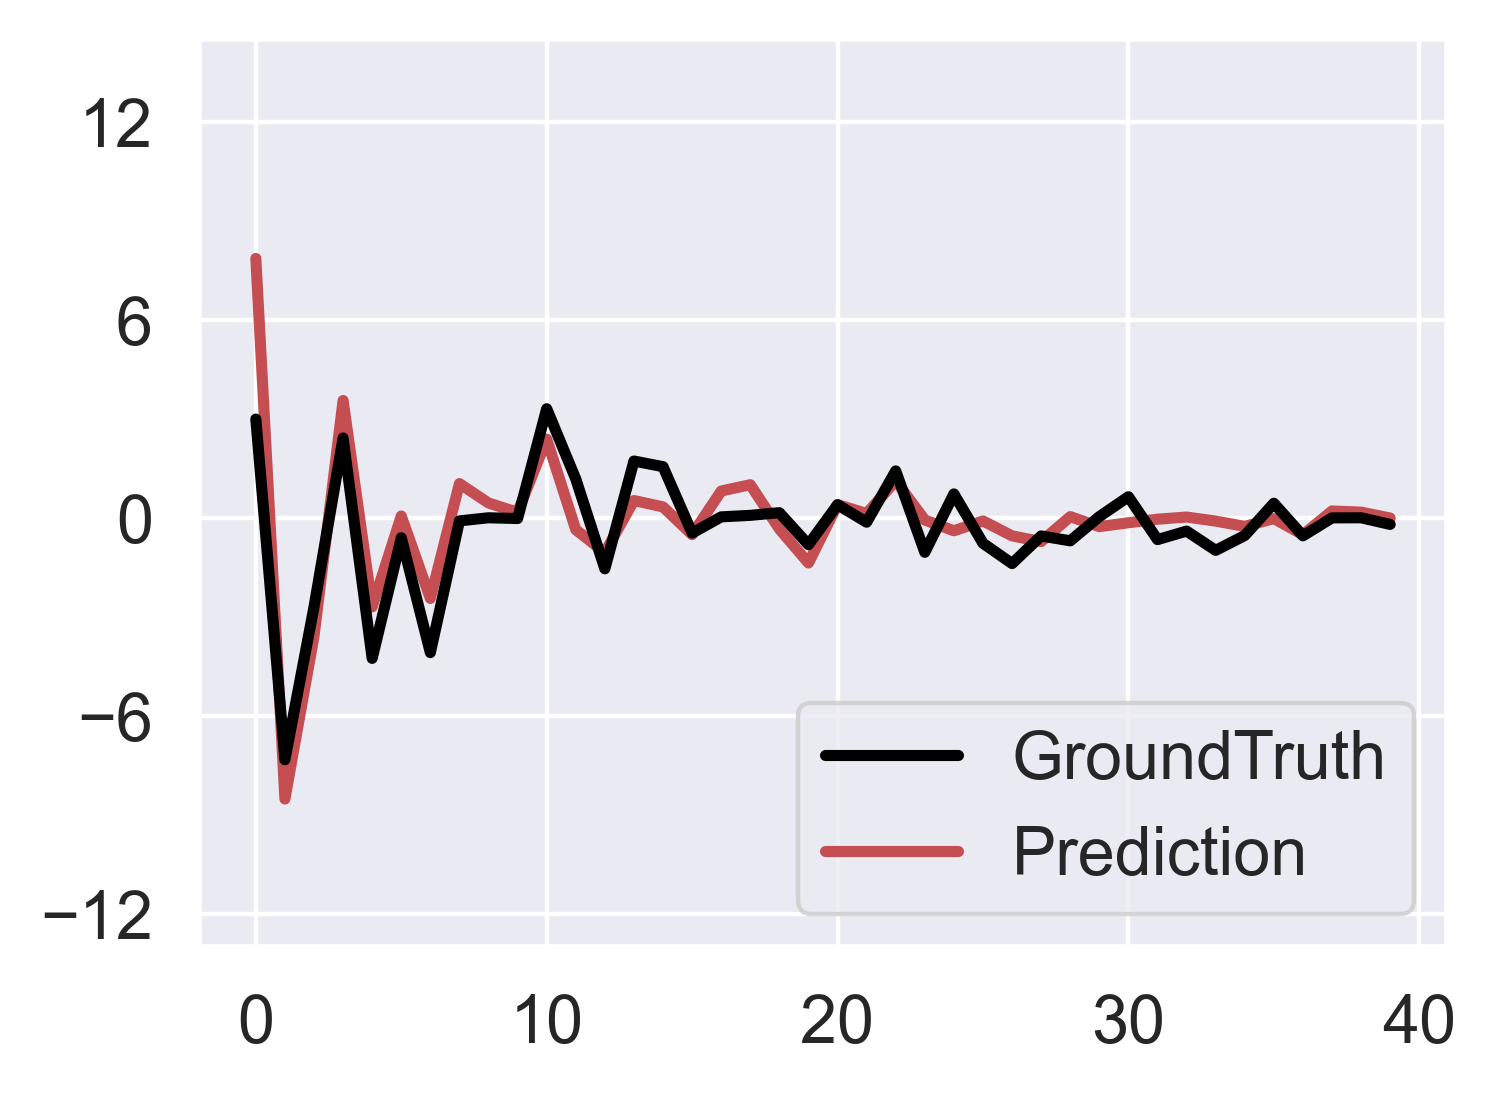

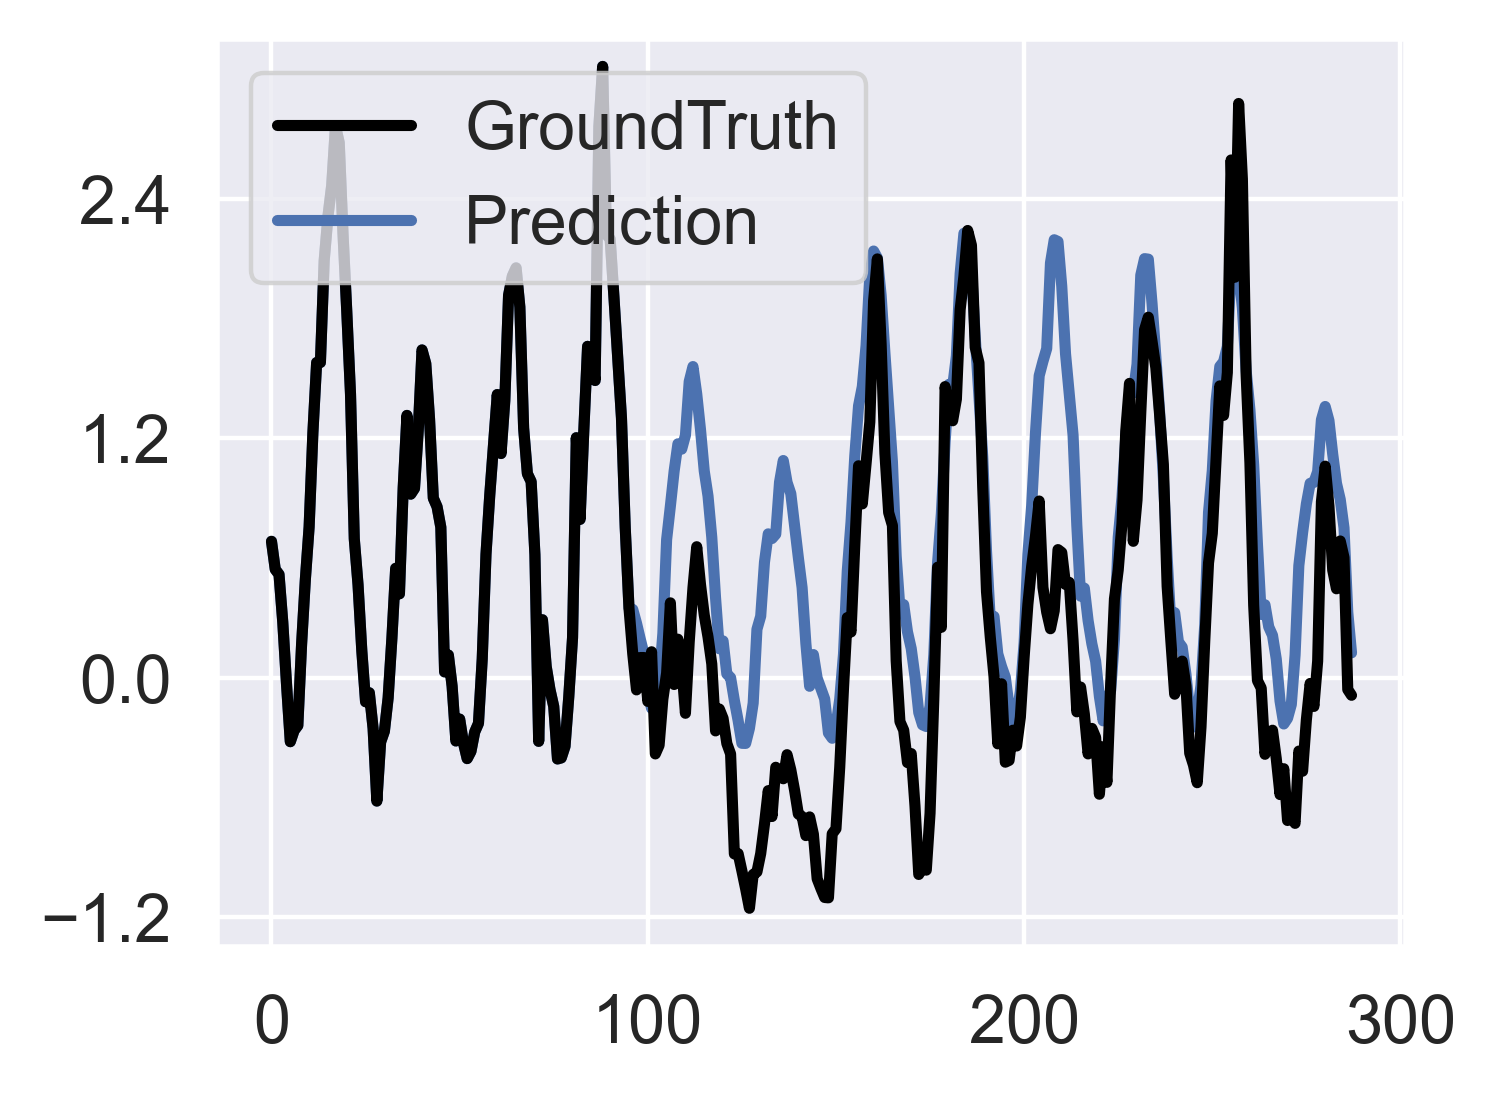

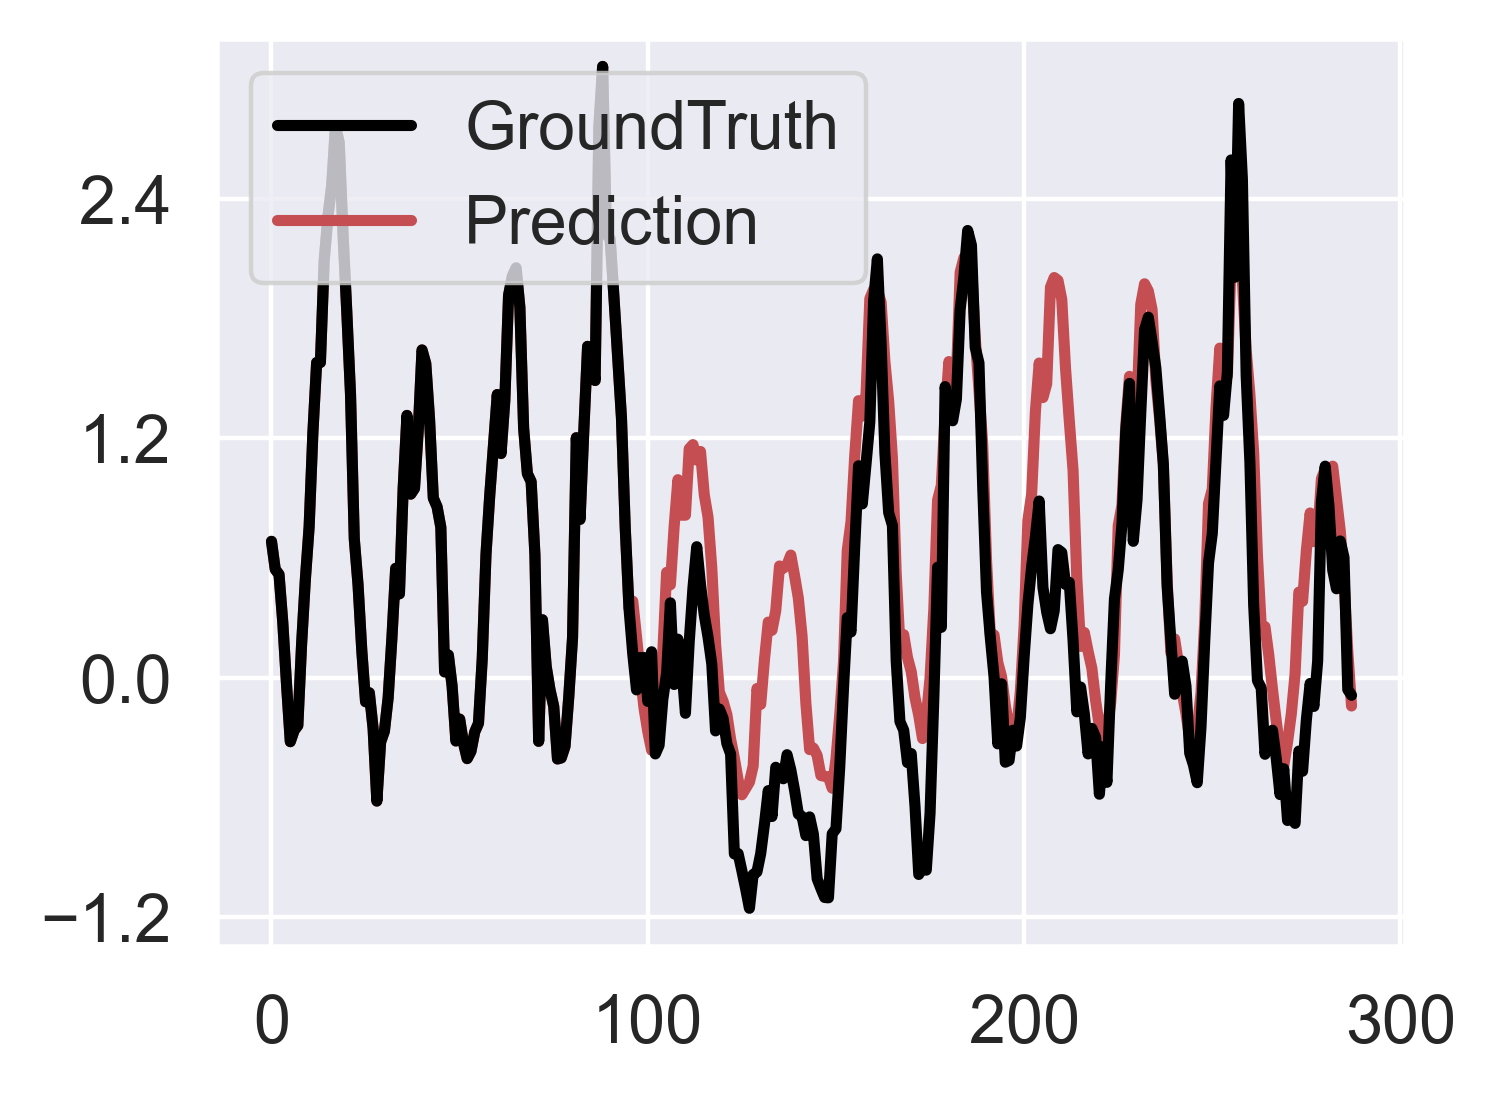

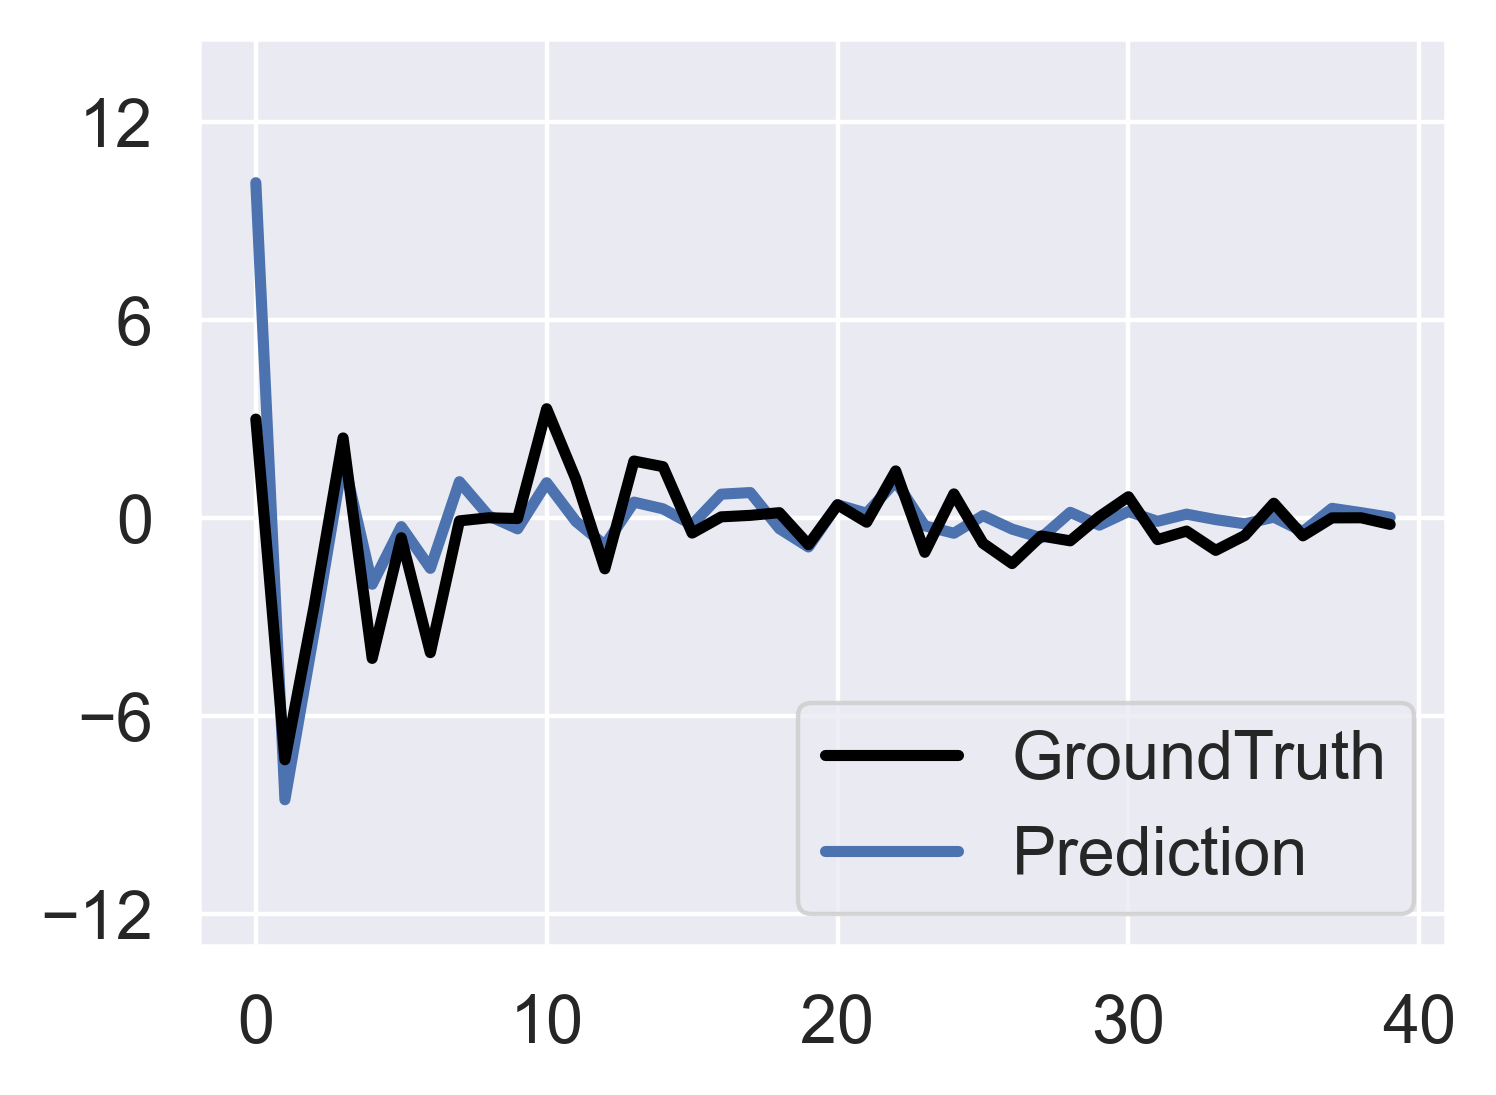

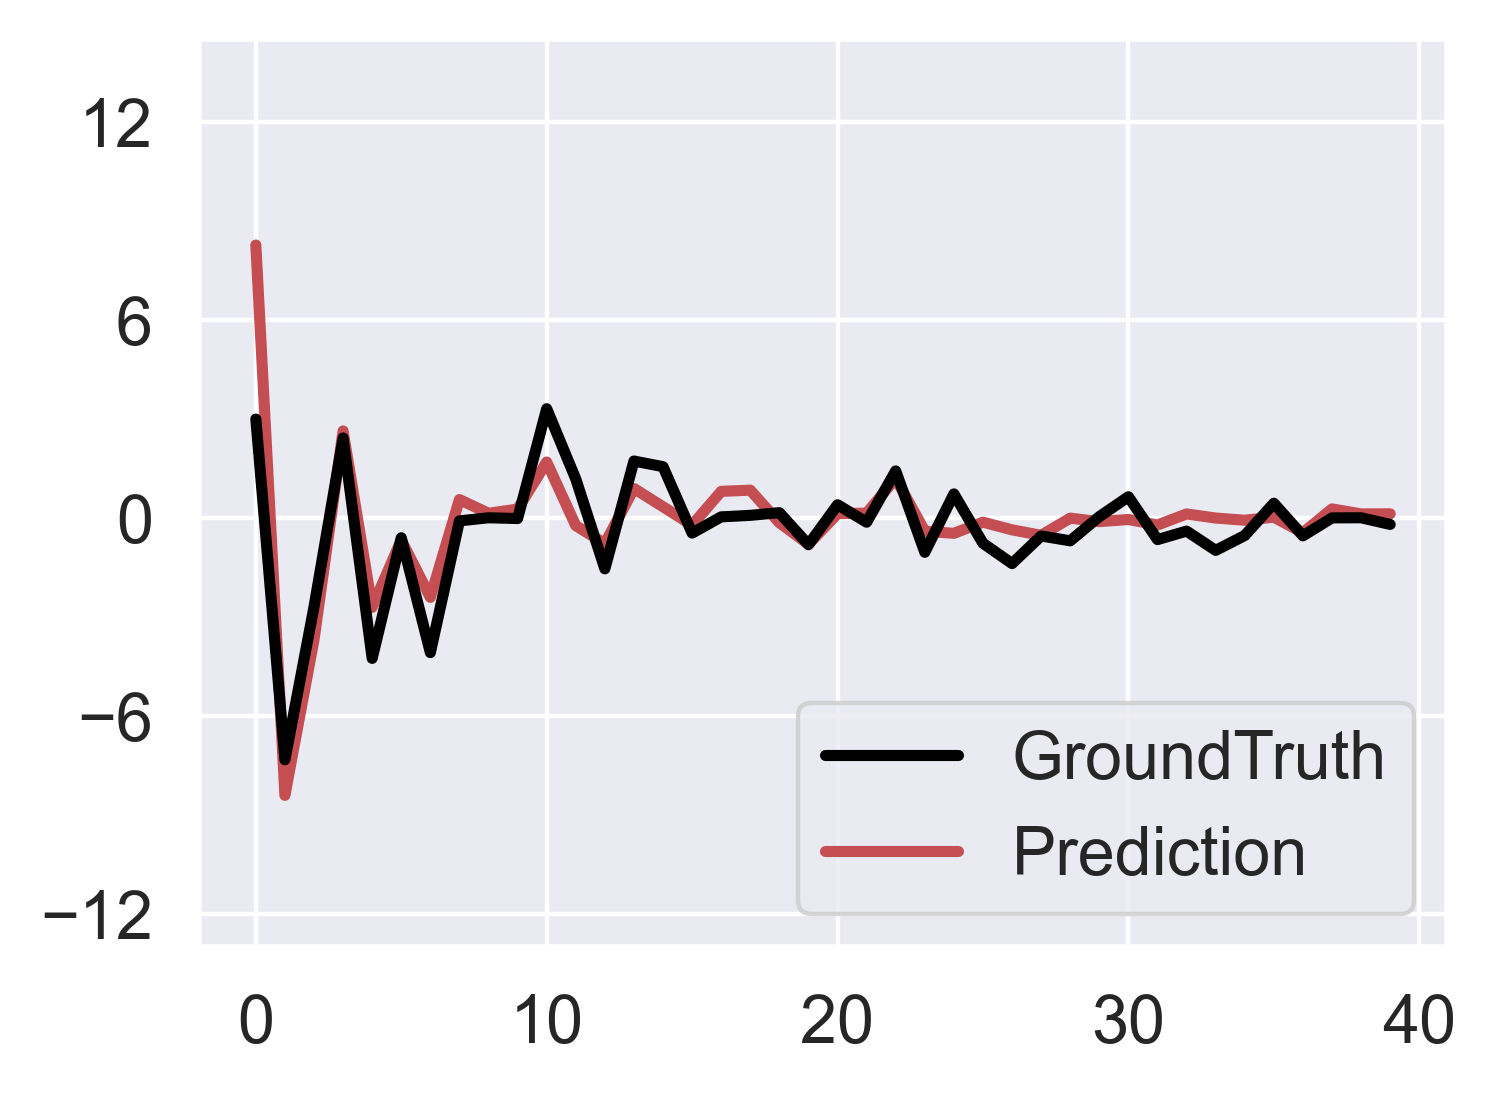

In [122]:
def plot(dataset, model, index, _save_dir, figure_name='predict', ypad=0, loc=None, limit=None, dpi=400, ylim=None):
    legend_location = 'upper left' if loc is None else loc
    labelsize = 12

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=dpi, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)

    f.add_subplot(1, 1, 1)
    d1 = [v for k, v in dataset.items() if 'PCA' not in k]
    true, preds = d1[0][0][index], d1[0][1][index]
    if limit is not None:
        true, preds = true[:limit], preds[:limit]

    plt.plot(true, label='GroundTruth', linewidth=2, color='black', zorder=2)
    plt.plot(preds, label='Prediction', linewidth=2, color=palette[1], zorder=1)
    ax = plt.gca()
    if ypad:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad))  # 小数点后3位数间隔。
    if ylim:
        plt.ylim(ylim)
    plt.legend(ncol=1, loc=legend_location, fontsize=labelsize)
    # plt.title(model, fontsize=14)
    plt.tick_params(labelsize=labelsize)

    plt.tight_layout()
    with PdfPages(os.path.join(_save_dir, f"{figure_name}_wo_PDF.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


    f = plt.figure(dpi=dpi, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)

    f.add_subplot(1, 1, 1)
    d1 = [v for k, v in dataset.items() if 'PCA' in k]
    true, preds = d1[0][0][index], d1[0][1][index]
    if limit is not None:
        true, preds = true[:limit], preds[:limit]

    plt.plot(true, label='GroundTruth', linewidth=2, color='black', zorder=2)
    plt.plot(preds, label='Prediction', linewidth=2, color=palette[0], zorder=1)
    ax = plt.gca()
    if ypad:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad))  # 小数点后3位数间隔。
    if ylim:
        plt.ylim(ylim)
    plt.legend(ncol=1, loc=legend_location, fontsize=labelsize)
    # plt.title(model + ' & PDF', fontsize=14)
    plt.tick_params(labelsize=labelsize)

    plt.tight_layout()
    with PdfPages(os.path.join(_save_dir, f"{figure_name}_w_PDF.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = os.path.join(figure_root, 'snapshots')
os.makedirs(save_dir, exist_ok=True)

DPI = 400

# index = 22
index = 2994

data_id = 'ETTm2'

pl = 336

# model = 'iTransformer'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"iTrans {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1.7, 0.45], ypad=0.5)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=5, ylim=[-20, 8])


# model = 'Fredformer'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"Fredformer {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1.7, 0.45], ypad=0.5)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=5, ylim=[-22, 8])




index = 22

data_id = 'ETTm2'

pl = 336

# model = 'iTransformer'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"iTrans {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1, 0.83], ypad=0.4)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=5, ylim=[-10.5, 7])


# model = 'Fredformer'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"Fredformer {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1, 0.83], ypad=0.4)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=5, ylim=[-10.5, 7])



# model = 'DLinear'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"DLinear {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'DLinear_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'DLinear_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad1=5, ypad2=5)



# model = 'FreTS'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"FreTS {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'FreTS_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'FreTS_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad1=5, ypad2=5)





DPI = 400

index = 604
# index = 2452

data_id = 'ECL'
pl = 192

# model = 'iTransformer'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"iTrans {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1.5, 2.9], ypad=1.2)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=5, ylim=[-13, 9])


# model = 'Fredformer'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"Fredformer {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1.5, 2.9], ypad=1.2)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=5, ylim=[-13, 9])



index = 2452

data_id = 'ECL'
pl = 192

model = 'iTransformer'
datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
print(f"iTrans {data_id} {pl} index {index}")
print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
plot(datap, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1.35, 3.2], ypad=1.2)

components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
plot(datap2, model, index, save_dir, figure_name=f'iTrans_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=6, ylim=[-13, 14.5])


model = 'Fredformer'
datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
print(f"Fredformer {data_id} {pl} index {index}")
print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
plot(datap, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI, ylim=[-1.35, 3.2], ypad=1.2)

components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
plot(datap2, model, index, save_dir, figure_name=f'Fred_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad=6, ylim=[-13, 14.5])



# model = 'DLinear'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"DLinear {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'DLinear_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'DLinear_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad1=5, ypad2=5)



# model = 'FreTS'
# datap = {k: data[k] for k in [f"{model}_{data_id}_{pl}", f"{model}_{data_id}_PCA_{pl}"]}
# print(f"FreTS {data_id} {pl} index {index}")
# print(np.mean(np.square(datap[f"{model}_{data_id}_{pl}"][0][:, -pl:] - datap[f"{model}_{data_id}_{pl}"][1][:, -pl:])))
# plot(datap, model, index, save_dir, figure_name=f'FreTS_{data_id}_{pl}_{index}', loc='upper left', dpi=DPI)

# components = data[f"{model}_{data_id}_PCA_{pl}_Base"]
# datap2 = {k: [np.dot(mat[:, -pl:], components.T) for mat in v] for k, v in datap.items()}
# plot(datap2, model, index, save_dir, figure_name=f'FreTS_{data_id}_{pl}_{index}_trans', loc='lower right', limit=40, dpi=DPI, ypad1=5, ypad2=5)